### Agriculture plays an important role in food production and the economy. Identifying different agricultural crops or plants manually can sometimes be difficult and time-consuming.

### "Many people are moving to cities for jobs and business opportunities. Because of this, they are becoming disconnected from agriculture. As a result, many people are not able to easily identify agricultural crops or plants from images."


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_generator = datagen.flow_from_directory("archive/Agricultural-crops/training",target_size=(64,64),class_mode='categorical')

Found 829 images belonging to 30 classes.


In [5]:
test_generator = datagen.flow_from_directory("archive/Agricultural-crops/testing",target_size=(64,64),class_mode='categorical')

Found 831 images belonging to 30 classes.


In [6]:
train_generator

In [7]:
data,label = next(train_generator)
data.shape

(32, 64, 64, 3)

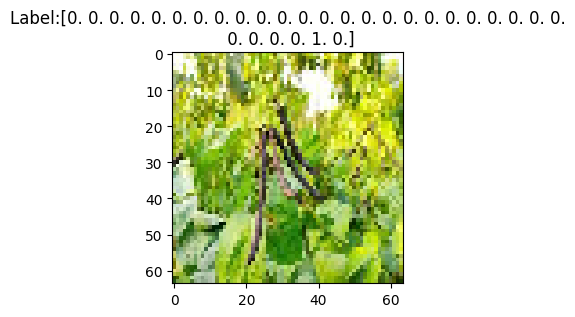

In [8]:
plt.figure(figsize=(3,3))
plt.imshow(data[2])  #from 32 images take first image
plt.title(f"Label:{label[2]}")   # take label of first image& show it as title of image
plt.show()

## CNN (Convolutional Neural Network) model

In [10]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu",input_shape=[64,64,3]))                #extract the feature
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))                                            #Image size reduce
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))
cnn.add(tf.keras.layers.Flatten())                                    # Flatten convert 2d vector ti 1 d 
cnn.add(tf.keras.layers.Dense(units=128,activation="relu"))           #learn complex pattern
cnn.add(tf.keras.layers.Dense(30, activation='softmax'))


C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(optimizer = "adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [14]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           3,870 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 816,958 (3.12 MB)

 Trainable params: 816,958 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   
    metrics=['accuracy']
)

In [30]:
result = cnn.fit(x = train_generator,epochs=7)                      


Epoch 1/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.4331 - loss: 2.0674
Epoch 2/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.5489 - loss: 1.7140
Epoch 3/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.6393 - loss: 1.3940
Epoch 4/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.7503 - loss: 1.0215
Epoch 5/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.8275 - loss: 0.7260
Epoch 6/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.9144 - loss: 0.4764
Epoch 7/7
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.9493 - loss: 0.3106


In [31]:
cnn.evaluate(test_generator)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.9567 - loss: 0.2507


[0.25072571635246277, 0.9566786885261536]

In [32]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Load image
new_image = load_img('archive/Agricultural-crops/Single Prediction/jwari1.jpeg',target_size=(64, 64))

# Convert to array
new_image = img_to_array(new_image)

# Rescale if you used rescale=1./255 during training
new_image = new_image / 255.0

# Add batch dimension
new_image = np.expand_dims(new_image, axis=0)



In [33]:
result = cnn.predict(new_image)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[1.2017037e-04 3.9780044e-04 2.5027255e-05 1.5724425e-05 9.0037440e-07
  8.2441494e-07 8.9028844e-04 3.3666824e-06 6.9463199e-06 2.0896252e-06
  6.2641595e-04 6.6419714e-05 1.2457349e-05 1.8440951e-06 4.8775267e-04
  3.6374480e-04 9.5488465e-01 4.8513799e-10 1.9242970e-08 8.5698364e-09
  1.6089460e-07 1.1783022e-04 4.7234880e-05 1.7309230e-03 5.9342533e-08
  5.1204041e-03 1.5255866e-06 5.0394255e-04 9.0986257e-03 2.5472891e-02]]


In [34]:
predicted_class_index = np.argmax(result)
print("Predicted Index:", predicted_class_index)


Predicted Index: 16


In [35]:
class_indices = train_generator.class_indices
print(class_indices)


{'Cherry': 0, 'Coffee-plant': 1, 'Cucumber': 2, 'Fox_nut(Makhana)': 3, 'Lemon': 4, 'Olive-tree': 5, 'Pearl_millet(bajra)': 6, 'Tobacco-plant': 7, 'almond': 8, 'banana': 9, 'cardamom': 10, 'chilli': 11, 'clove': 12, 'coconut': 13, 'cotton': 14, 'gram': 15, 'jowar': 16, 'jute': 17, 'maize': 18, 'mustard-oil': 19, 'papaya': 20, 'pineapple': 21, 'rice': 22, 'soyabean': 23, 'sugarcane': 24, 'sunflower': 25, 'tea': 26, 'tomato': 27, 'vigna-radiati(Mung)': 28, 'wheat': 29}


Predicted Crop: jowar
